## 1. Imports and Setup

In [ ]:
import numpy as np
import pandas as pd
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

np.random.seed(42)
tf.random.set_seed(42)

EPOCHS = 15
BATCH_SIZE = 128
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Dataset and Experimental Setup


In [ ]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

x_train_full = x_train_full.astype('float32') / 255.0
x_test_full = x_test_full.astype('float32') / 255.0

N_TRAIN = 10000
N_VAL = 2000
N_TEST = 2000

# Keep the test set completely unseen during training.
x_train = x_train_full[:N_TRAIN]
y_train = y_train_full[:N_TRAIN]
x_val = x_train_full[N_TRAIN:N_TRAIN + N_VAL]
y_val = y_train_full[N_TRAIN:N_TRAIN + N_VAL]
x_test = x_test_full[:N_TEST]
y_test = y_test_full[:N_TEST]

# Flattened version for the fully connected autoencoder: x in R^784
x_train_flat = x_train.reshape(-1, 784)
x_val_flat = x_val.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

# Spatial version for convolutional models: x in R^(28x28x1)
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_val_cnn = x_val.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

print("Train shape (flat):", x_train_flat.shape, " Validation:", x_val_flat.shape, " Test:", x_test_flat.shape)
print("Train shape (cnn) :", x_train_cnn.shape, " Validation:", x_val_cnn.shape, " Test:", x_test_cnn.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape (flat): (10000, 784)  Validation: (2000, 784)  Test: (2000, 784)
Train shape (cnn) : (10000, 28, 28, 1)  Validation: (2000, 28, 28, 1)  Test: (2000, 28, 28, 1)


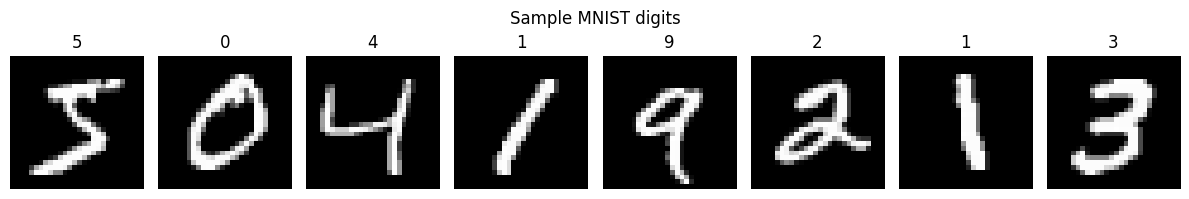

In [ ]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(str(y_train[i]))
    ax.axis('off')
plt.suptitle('Sample MNIST digits')
plt.tight_layout()
plt.show()

In [ ]:
def compute_metrics(originals, reconstructions, n_ssim=500):
    """originals, reconstructions: arrays of shape (N, 28, 28, 1) with values in [0,1]"""
    mse = np.mean((originals - reconstructions) ** 2)
    mae = np.mean(np.abs(originals - reconstructions))

    n = len(originals)
    idx = np.arange(min(n_ssim, n))
    ssim_vals = []
    for i in idx:
        o = originals[i].squeeze()
        r = reconstructions[i].squeeze()
        ssim_vals.append(ssim(o, r, data_range=1.0))
    mean_ssim = float(np.mean(ssim_vals))
    return float(mse), float(mae), mean_ssim

In [ ]:
LATENT_DIM_FC = 16

def build_fc_autoencoder(latent_dim=16):
    inputs = keras.Input(shape=(784,))
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(32, activation='relu')(x)
    z = layers.Dense(latent_dim, activation='relu', name='latent')(x)
    x = layers.Dense(32, activation='relu')(z)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(784, activation='sigmoid')(x)
    model = keras.Model(inputs, outputs, name='fc_autoencoder')
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
    return model

fc_ae = build_fc_autoencoder(LATENT_DIM_FC)
fc_ae.summary()

Model: "fc_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start = time.time()
history_fc = fc_ae.fit(
    x_train_flat, x_train_flat,
    validation_data=(x_val_flat, x_val_flat),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1
)
time_fc = time.time() - start
print(f"FC-AE training time: {time_fc:.1f}s")

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.3348 - val_loss: 0.2515
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2348 - val_loss: 0.2134
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1993 - val_loss: 0.1832
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1777 - val_loss: 0.1693
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1676 - val_loss: 0.1619
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1615 - val_loss: 0.1569
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1568 - val_loss: 0.1524
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1524 - val_loss: 0.1480
Epoch 9/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1483 - val_loss: 0.1443
Epoch 10/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1452 - val_loss: 0.1418
Epoch 11/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1426 - val_loss: 0.1394
Epoch 12/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1402 - val_l

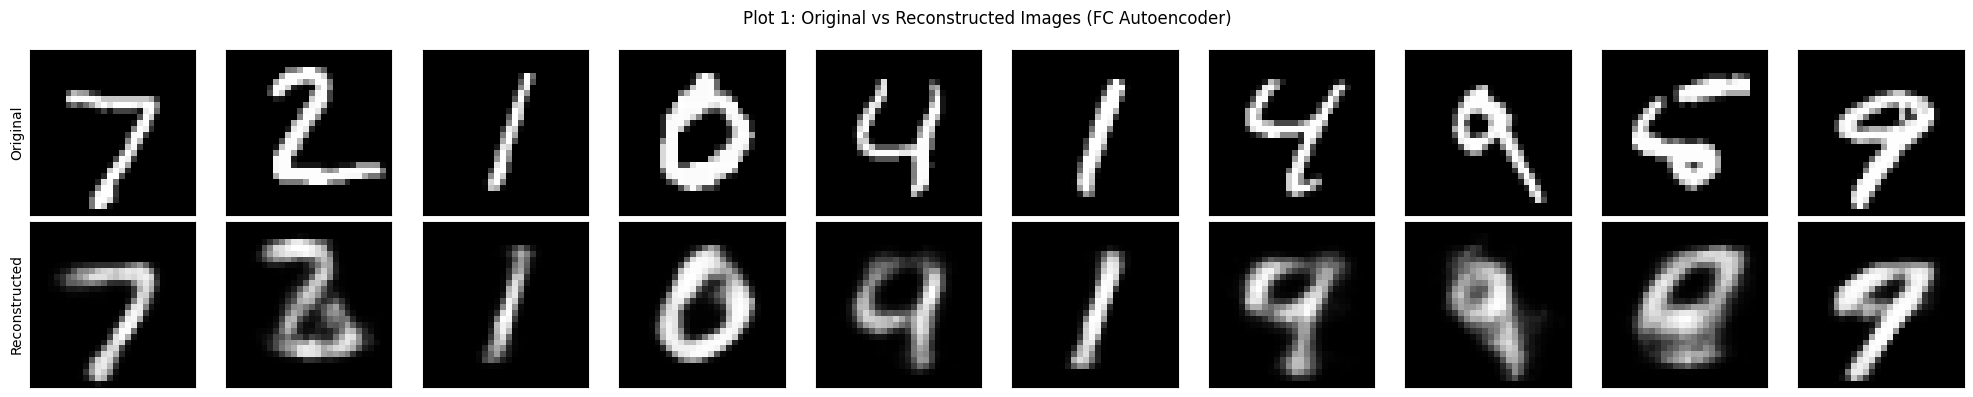

In [ ]:
recon_fc_imgs = fc_ae.predict(x_test_flat[:10], verbose=0)

fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([])
    axes[1, i].imshow(recon_fc_imgs[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])
axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('Reconstructed')
plt.suptitle('Plot 1: Original vs Reconstructed Images (FC Autoencoder)')
plt.tight_layout()
plt.show()

**Plot 2: Training and Validation Reconstruction Loss**

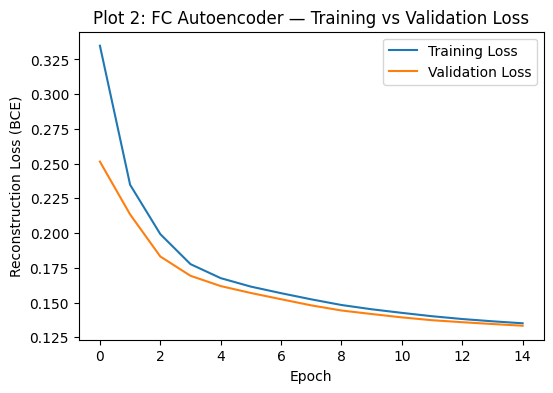

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history_fc.history['loss'], label='Training Loss')
plt.plot(history_fc.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss (BCE)')
plt.title('Plot 2: FC Autoencoder — Training vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
recon_fc_test = fc_ae.predict(x_test_flat, verbose=0)
mse_fc, mae_fc, ssim_fc = compute_metrics(
    x_test_flat.reshape(-1, 28, 28, 1), recon_fc_test.reshape(-1, 28, 28, 1)
)

fc_metrics_df = pd.DataFrame({
    'Metric': ['Test MSE', 'Test MAE', 'Mean SSIM'],
    'Value': [mse_fc, mae_fc, ssim_fc]
})
fc_metrics_df

,Metric,Value
0,Test MSE,0.025793
1,Test MAE,0.065904
2,Mean SSIM,0.697924


In [ ]:
def build_conv_autoencoder():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    outputs = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
    model = keras.Model(inputs, outputs, name='conv_autoencoder')
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
    return model

cae = build_conv_autoencoder()
cae.summary()

Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start = time.time()
history_cae = cae.fit(
    x_train_cnn, x_train_cnn,
    validation_data=(x_val_cnn, x_val_cnn),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1
)
time_cae = time.time() - start
print(f"CAE training time: {time_cae:.1f}s")

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - loss: 0.2131 - val_loss: 0.0994
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0916 - val_loss: 0.0837
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0825 - val_loss: 0.0784
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0783 - val_loss: 0.0751
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0759 - val_loss: 0.0732
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0744 - val_loss: 0.0730
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0735 - val_loss: 0.0716
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0726 - val_loss: 0.0708
Epoch 9/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0719 - val_loss: 0.0701
Epoch 10/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0714 - val_loss: 0.0696
Epoch 11/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0709 - val_loss: 0.0692
Epoch 12/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0705 - val_l

In [ ]:
recon_cae_test = cae.predict(x_test_cnn, verbose=0)
mse_cae, mae_cae, ssim_cae = compute_metrics(x_test_cnn, recon_cae_test)

comparison_df = pd.DataFrame({
    'Model': ['Fully Connected AE', 'Convolutional AE'],
    'MSE': [mse_fc, mse_cae],
    'MAE': [mae_fc, mae_cae],
    'SSIM': [ssim_fc, ssim_cae],
    'Parameters': [fc_ae.count_params(), cae.count_params()]
})
comparison_df

,Model,MSE,MAE,SSIM,Parameters
0,Fully Connected AE,0.025793,0.065904,0.697924,211040
1,Convolutional AE,0.002881,0.015834,0.971676,74497


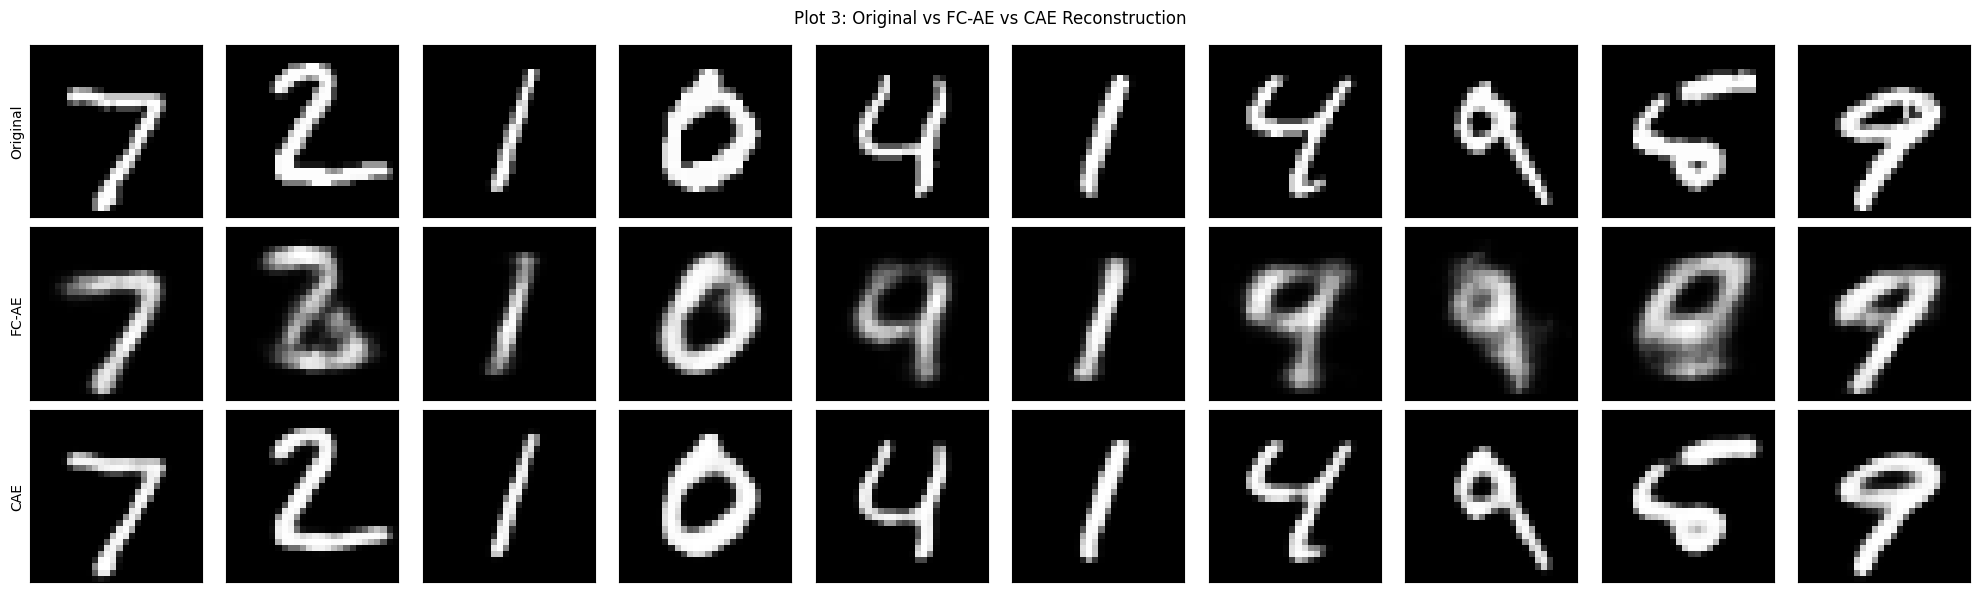

In [ ]:
recon_fc_10 = fc_ae.predict(x_test_flat[:10], verbose=0).reshape(-1, 28, 28)
recon_cae_10 = cae.predict(x_test_cnn[:10], verbose=0).reshape(-1, 28, 28)

fig, axes = plt.subplots(3, 10, figsize=(20, 6))
for i in range(10):
    axes[0, i].imshow(x_test[i], cmap='gray'); axes[0, i].set_xticks([]); axes[0, i].set_yticks([])
    axes[1, i].imshow(recon_fc_10[i], cmap='gray'); axes[1, i].set_xticks([]); axes[1, i].set_yticks([])
    axes[2, i].imshow(recon_cae_10[i], cmap='gray'); axes[2, i].set_xticks([]); axes[2, i].set_yticks([])
axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('FC-AE')
axes[2, 0].set_ylabel('CAE')
plt.suptitle('Plot 3: Original vs FC-AE vs CAE Reconstruction')
plt.tight_layout()
plt.show()

In [ ]:
def add_gaussian_noise(images, sigma):
    noisy = images + np.random.normal(0.0, sigma, images.shape)
    return np.clip(noisy, 0.0, 1.0)

def add_salt_pepper_noise(images, p):
    noisy = images.copy()
    mask = np.random.random(images.shape)
    noisy[mask < p / 2] = 0.0
    noisy[(mask >= p / 2) & (mask < p)] = 1.0
    return noisy

In [ ]:
SIGMA_TRAIN = 0.2
SP_TRAIN = 0.10

# Use both required corruption types while keeping the same number of training images.
rng = np.random.default_rng(42)
use_sp = rng.random(len(x_train_cnn)) < 0.5
x_train_noisy = add_gaussian_noise(x_train_cnn, SIGMA_TRAIN)
x_train_noisy[use_sp] = add_salt_pepper_noise(x_train_cnn[use_sp], SP_TRAIN)

# Validation uses a fixed mixture of the two corruption types.
x_val_noisy = add_gaussian_noise(x_val_cnn, SIGMA_TRAIN)
val_use_sp = rng.random(len(x_val_cnn)) < 0.5
x_val_noisy[val_use_sp] = add_salt_pepper_noise(x_val_cnn[val_use_sp], SP_TRAIN)

# Separate Gaussian test set for the required noise-level study.
x_test_noisy = add_gaussian_noise(x_test_cnn, SIGMA_TRAIN)

denoise_cae = build_conv_autoencoder()

start = time.time()
history_denoise = denoise_cae.fit(
    x_train_noisy, x_train_cnn,
    validation_data=(x_val_noisy, x_val_cnn),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1
)
time_denoise = time.time() - start
print(f"Denoising CAE training time: {time_denoise:.1f}s")


Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.2474 - val_loss: 0.1185
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1069 - val_loss: 0.0972
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0946 - val_loss: 0.0898
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0898 - val_loss: 0.0861
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0866 - val_loss: 0.0846
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0845 - val_loss: 0.0823
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0830 - val_loss: 0.0816
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0819 - val_loss: 0.0805
Epoch 9/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0810 - val_loss: 0.0801
Epoch 10/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0803 - val_loss: 0.0789
Epoch 11/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0796 - val_loss: 0.0786
Epoch 12/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0791 - val_l

**Plot 4: Clean vs Noisy vs Denoised**

Display at least 10 test images. The displayed examples use Gaussian noise for easy visual comparison.


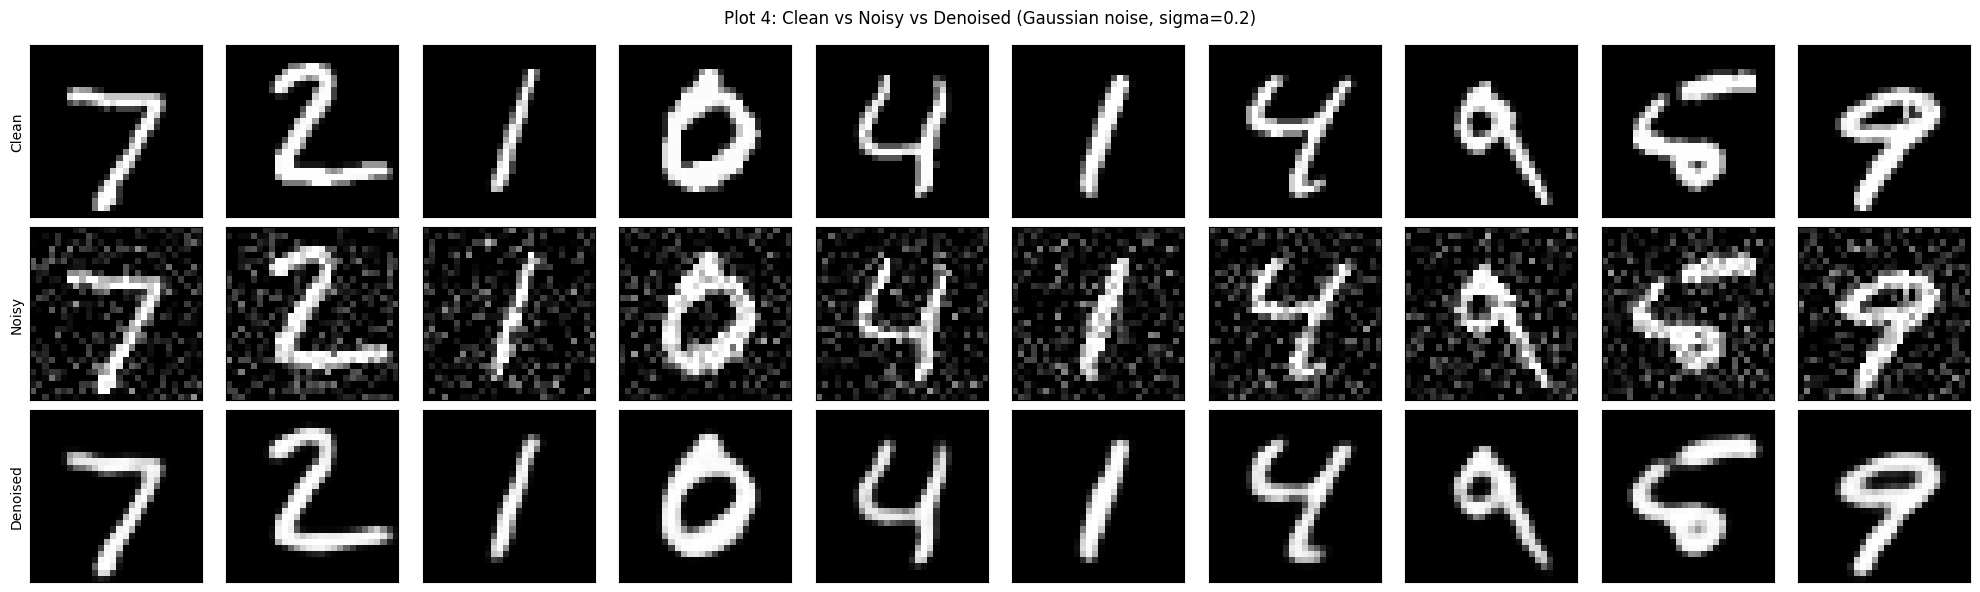

In [ ]:
denoised_10 = denoise_cae.predict(x_test_noisy[:10], verbose=0).reshape(-1, 28, 28)
noisy_10 = x_test_noisy[:10].reshape(-1, 28, 28)

fig, axes = plt.subplots(3, 10, figsize=(20, 6))
for i in range(10):
    axes[0, i].imshow(x_test[i], cmap='gray'); axes[0, i].set_xticks([]); axes[0, i].set_yticks([])
    axes[1, i].imshow(noisy_10[i], cmap='gray'); axes[1, i].set_xticks([]); axes[1, i].set_yticks([])
    axes[2, i].imshow(denoised_10[i], cmap='gray'); axes[2, i].set_xticks([]); axes[2, i].set_yticks([])
axes[0, 0].set_ylabel('Clean')
axes[1, 0].set_ylabel('Noisy')
axes[2, 0].set_ylabel('Denoised')
plt.suptitle('Plot 4: Clean vs Noisy vs Denoised (Gaussian noise, sigma=0.2)')
plt.tight_layout()
plt.show()

**Plot 5: Noise Level vs Reconstruction Quality (Gaussian noise)**

In [ ]:
noise_levels = [0.1, 0.2, 0.3]
noise_results = []
for sigma in noise_levels:
    x_test_n = add_gaussian_noise(x_test_cnn, sigma)
    recon_n = denoise_cae.predict(x_test_n, verbose=0)
    mse_n, mae_n, ssim_n = compute_metrics(x_test_cnn, recon_n)
    noise_results.append({'Noise Level': sigma, 'MSE': mse_n, 'MAE': mae_n, 'SSIM': ssim_n})

noise_df = pd.DataFrame(noise_results)
noise_df

,Noise Level,MSE,MAE,SSIM
0,0.1,0.004055,0.019069,0.956045
1,0.2,0.005171,0.022644,0.939838
2,0.3,0.007698,0.030203,0.878906


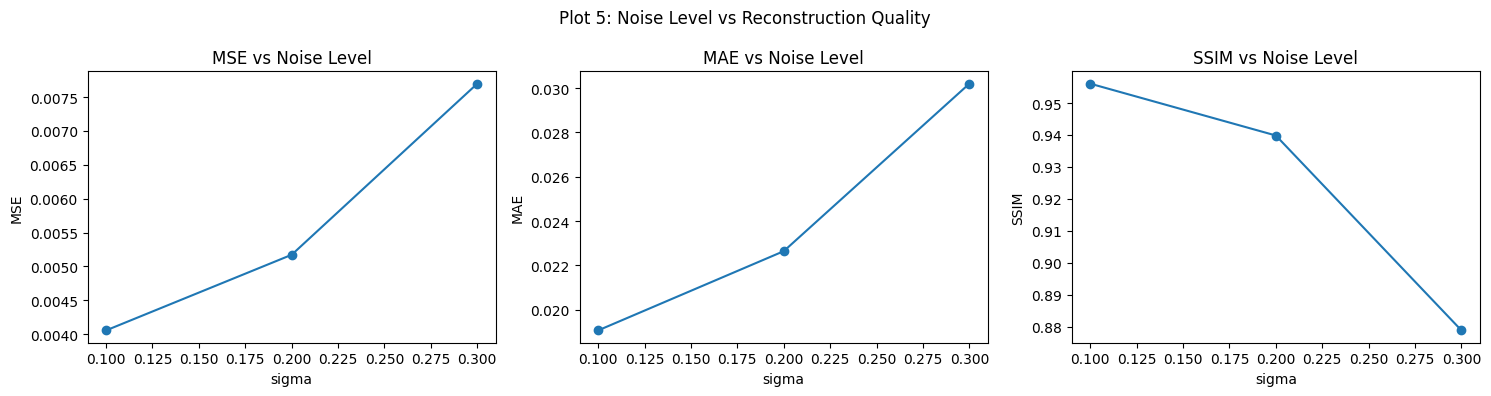

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(noise_df['Noise Level'], noise_df['MSE'], marker='o'); axes[0].set_title('MSE vs Noise Level'); axes[0].set_xlabel('sigma'); axes[0].set_ylabel('MSE')
axes[1].plot(noise_df['Noise Level'], noise_df['MAE'], marker='o'); axes[1].set_title('MAE vs Noise Level'); axes[1].set_xlabel('sigma'); axes[1].set_ylabel('MAE')
axes[2].plot(noise_df['Noise Level'], noise_df['SSIM'], marker='o'); axes[2].set_title('SSIM vs Noise Level'); axes[2].set_xlabel('sigma'); axes[2].set_ylabel('SSIM')
plt.suptitle('Plot 5: Noise Level vs Reconstruction Quality')
plt.tight_layout()
plt.show()

Salt-and-Pepper (p=0.10) evaluated on the mixed-noise denoiser: MSE=0.00590  MAE=0.02365  SSIM=0.9262


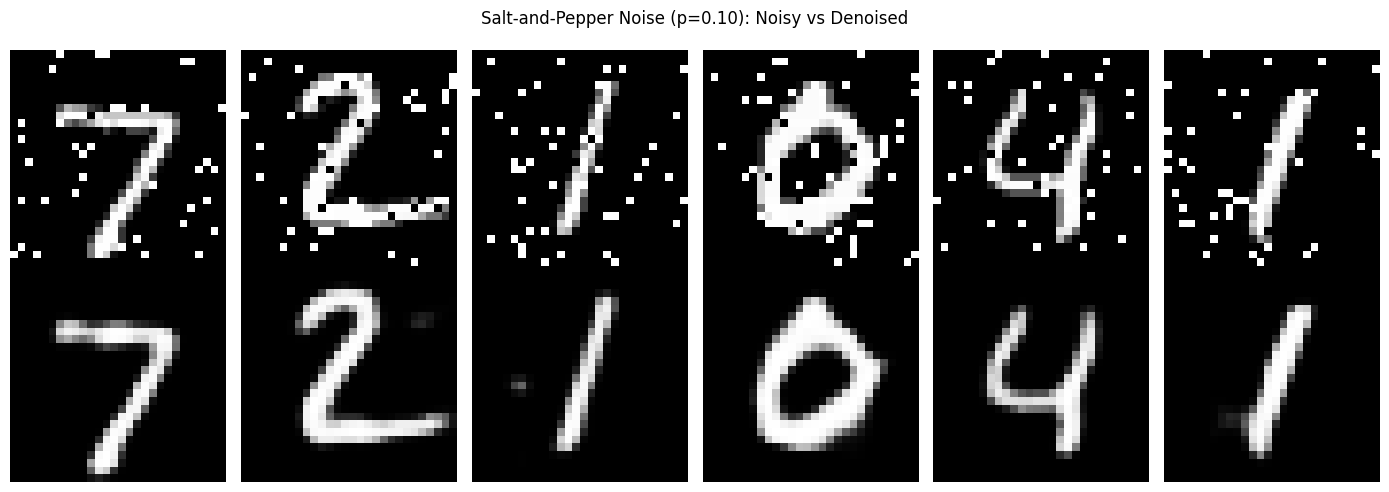

In [ ]:
x_test_sp = add_salt_pepper_noise(x_test_cnn, p=0.10)
recon_sp = denoise_cae.predict(x_test_sp, verbose=0)
mse_sp, mae_sp, ssim_sp = compute_metrics(x_test_cnn, recon_sp)
print(f"Salt-and-Pepper (p=0.10) evaluated on the mixed-noise denoiser: "
      f"MSE={mse_sp:.5f}  MAE={mae_sp:.5f}  SSIM={ssim_sp:.4f}")

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i in range(6):
    axes[0, i].imshow(x_test_sp[i].reshape(28, 28), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(recon_sp[i].reshape(28, 28), cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_ylabel('Noisy (S&P)')
axes[1, 0].set_ylabel('Denoised')
plt.suptitle('Salt-and-Pepper Noise (p=0.10): Noisy vs Denoised')
plt.tight_layout()
plt.show()

In [ ]:
LATENT_DIM_VAE = 2

class Sampling(layers.Layer):
    """Reparameterization trick: z = mu + sigma * epsilon"""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

#  Encoder
enc_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(enc_inputs)
x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation='relu')(x)
z_mean = layers.Dense(LATENT_DIM_VAE, name='z_mean')(x)
z_log_var = layers.Dense(LATENT_DIM_VAE, name='z_log_var')(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(enc_inputs, [z_mean, z_log_var, z], name='encoder')

#  Decoder
dec_inputs = keras.Input(shape=(LATENT_DIM_VAE,))
x = layers.Dense(7 * 7 * 64, activation='relu')(dec_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
x = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)
dec_outputs = layers.Conv2DTranspose(1, 3, activation='sigmoid', padding='same')(x)
decoder = keras.Model(dec_inputs, dec_outputs, name='decoder')

encoder.summary()
decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name='loss')
        self.recon_loss_tracker = keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def _compute_losses(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(keras.losses.binary_crossentropy(x, reconstruction), axis=(1, 2))
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        x = data
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(x)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {'loss': self.total_loss_tracker.result(),
                'recon_loss': self.recon_loss_tracker.result(),
                'kl_loss': self.kl_loss_tracker.result()}

    def test_step(self, data):
        x = data
        total_loss, recon_loss, kl_loss = self._compute_losses(x)
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {'loss': self.total_loss_tracker.result(),
                'recon_loss': self.recon_loss_tracker.result(),
                'kl_loss': self.kl_loss_tracker.result()}

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(1e-3))

In [ ]:
start = time.time()
history_vae = vae.fit(
    x_train_cnn,
    validation_data=(x_val_cnn,),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1
)
time_vae = time.time() - start
print(f"VAE training time: {time_vae:.1f}s")

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - kl_loss: 2.3798 - loss: 301.1238 - recon_loss: 298.7439 - val_kl_loss: 2.4680 - val_loss: 213.3817 - val_recon_loss: 210.9137
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 2.8354 - loss: 208.6100 - recon_loss: 205.7746 - val_kl_loss: 3.2875 - val_loss: 203.2903 - val_recon_loss: 200.0029
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 3.3642 - loss: 200.9809 - recon_loss: 197.6168 - val_kl_loss: 3.8101 - val_loss: 197.8995 - val_recon_loss: 194.0894
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 3.4106 - loss: 197.3230 - recon_loss: 193.9124 - val_kl_loss: 3.5166 - val_loss: 194.7293 - val_recon_loss: 191.2127
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 3.3855 - loss: 194.9458 - recon_loss: 191.5603 - val_kl_loss: 3.5460 - val_loss: 192.9724 - val_recon_loss: 189.4263
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 3.4540 - loss: 192.8345 - recon_loss: 189.3805 

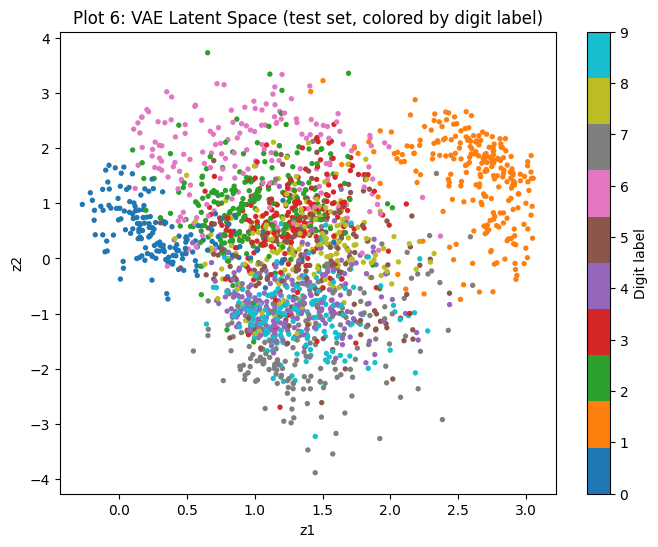

In [ ]:
z_mean_test, z_log_var_test, z_sample_test = encoder.predict(x_test_cnn, verbose=0)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(z_mean_test[:, 0], z_mean_test[:, 1], c=y_test, cmap='tab10', s=8)
plt.colorbar(scatter, label='Digit label')
plt.xlabel('z1')
plt.ylabel('z2')
plt.title('Plot 6: VAE Latent Space (test set, colored by digit label)')
plt.show()

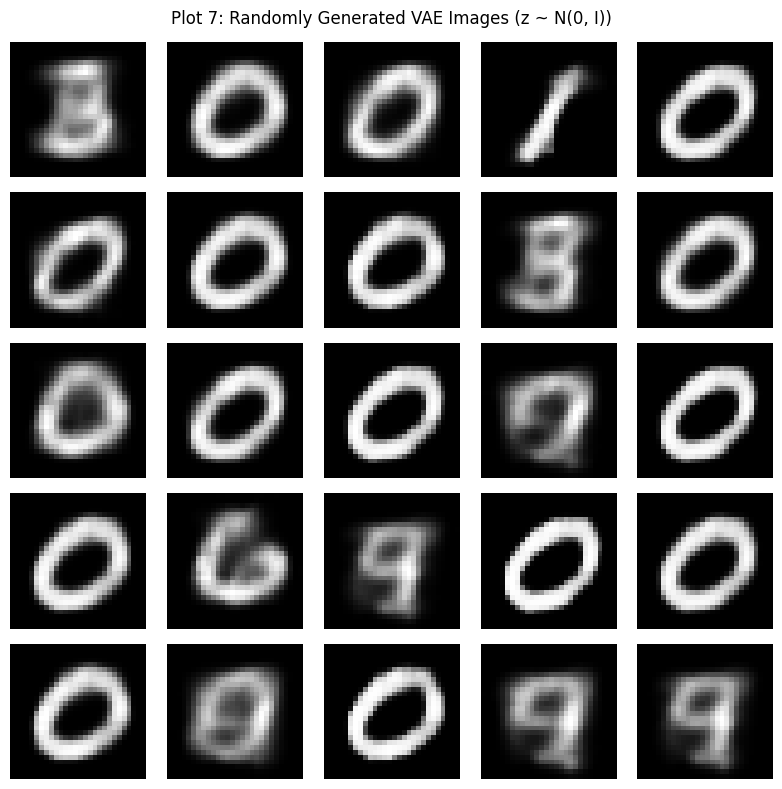

In [ ]:
n_generate = 25
random_latents = np.random.normal(size=(n_generate, LATENT_DIM_VAE))
generated_imgs = decoder.predict(random_latents, verbose=0)

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.suptitle('Plot 7: Randomly Generated VAE Images (z ~ N(0, I))')
plt.tight_layout()
plt.show()

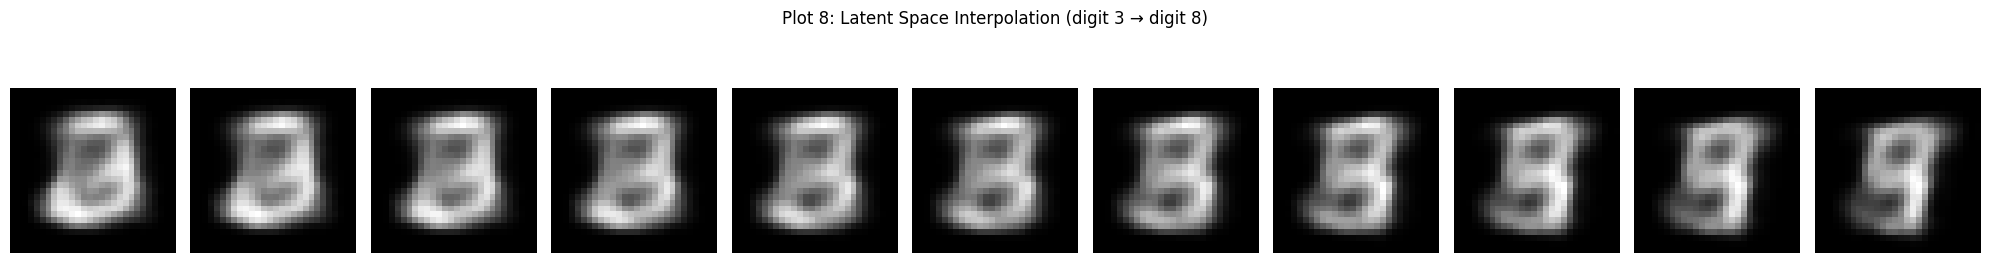

In [ ]:
digit_a, digit_b = 3, 8
zA = z_mean_test[y_test == digit_a][0]
zB = z_mean_test[y_test == digit_b][0]

alphas = np.arange(0.0, 1.01, 0.1)
interp_latents = np.array([(1 - a) * zA + a * zB for a in alphas])
interp_imgs = decoder.predict(interp_latents, verbose=0)

fig, axes = plt.subplots(1, len(alphas), figsize=(20, 3))
for i, ax in enumerate(axes):
    ax.imshow(interp_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.suptitle(f'Plot 8: Latent Space Interpolation (digit {digit_a} → digit {digit_b})')
plt.tight_layout()
plt.show()

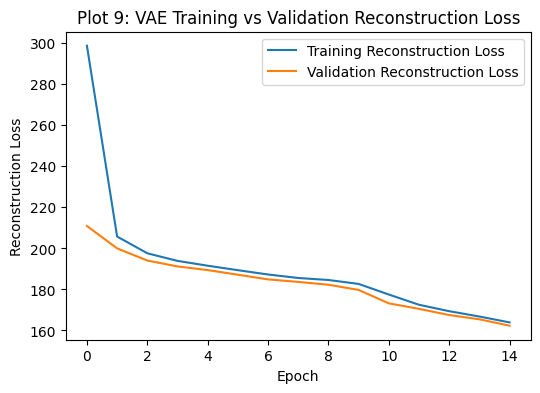

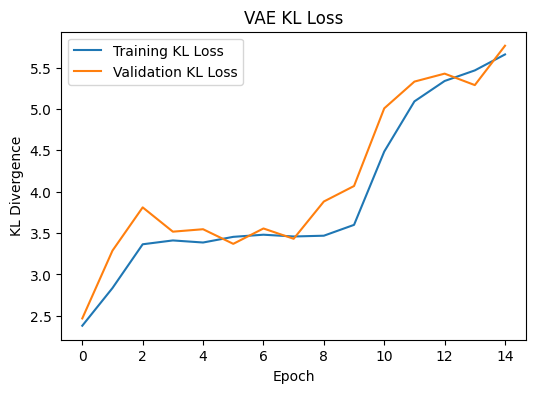

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history_vae.history['recon_loss'], label='Training Reconstruction Loss')
plt.plot(history_vae.history['val_recon_loss'], label='Validation Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.title('Plot 9: VAE Training vs Validation Reconstruction Loss')
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history_vae.history['kl_loss'], label='Training KL Loss')
plt.plot(history_vae.history['val_kl_loss'], label='Validation KL Loss')
plt.xlabel('Epoch')
plt.ylabel('KL Divergence')
plt.title('VAE KL Loss')
plt.legend()
plt.show()


In [ ]:
# Denoising CAE metrics (clean-vs-denoised on the Gaussian sigma=0.2 test set)
recon_denoise_test = denoise_cae.predict(x_test_noisy, verbose=0)
mse_dn, mae_dn, ssim_dn = compute_metrics(x_test_cnn, recon_denoise_test)

model_comparison_df = pd.DataFrame({
    'Model': ['Fully Connected AE', 'Convolutional AE', 'Denoising CAE'],
    'MSE': [mse_fc, mse_cae, mse_dn],
    'MAE': [mae_fc, mae_cae, mae_dn],
    'SSIM': [ssim_fc, ssim_cae, ssim_dn],
    'Parameters': [fc_ae.count_params(), cae.count_params(), denoise_cae.count_params()]
})
model_comparison_df

,Model,MSE,MAE,SSIM,Parameters
0,Fully Connected AE,0.025793,0.065904,0.697924,211040
1,Convolutional AE,0.002881,0.015834,0.971676,74497
2,Denoising CAE,0.005158,0.022615,0.940166,74497


In [ ]:
# VAE metrics (reported separately, since its objective also includes the KL term)
z_mean_t, z_log_var_t, _ = encoder.predict(x_test_cnn, verbose=0)
recon_vae_test = decoder.predict(z_mean_t, verbose=0)  # use the mean for deterministic reconstruction

recon_loss_vae = float(np.mean(np.sum(
    keras.losses.binary_crossentropy(x_test_cnn, recon_vae_test), axis=(1, 2)
)))
kl_loss_vae = float(-0.5 * np.mean(np.sum(
    1 + z_log_var_t - np.square(z_mean_t) - np.exp(z_log_var_t), axis=1
)))
total_loss_vae = recon_loss_vae + kl_loss_vae

mse_vae, mae_vae, ssim_vae = compute_metrics(x_test_cnn, recon_vae_test)

vae_metrics_df = pd.DataFrame({
    'VAE Metric': ['Reconstruction Loss', 'KL Loss', 'Total Loss', 'Test MSE', 'Test MAE', 'Mean SSIM'],
    'Value': [recon_loss_vae, kl_loss_vae, total_loss_vae, mse_vae, mae_vae, ssim_vae]
})
vae_metrics_df

,VAE Metric,Value
0,Reconstruction Loss,160.586868
1,KL Loss,5.683106
2,Total Loss,166.269974
3,Test MSE,0.048956
4,Test MAE,0.114731
5,Mean SSIM,0.411750


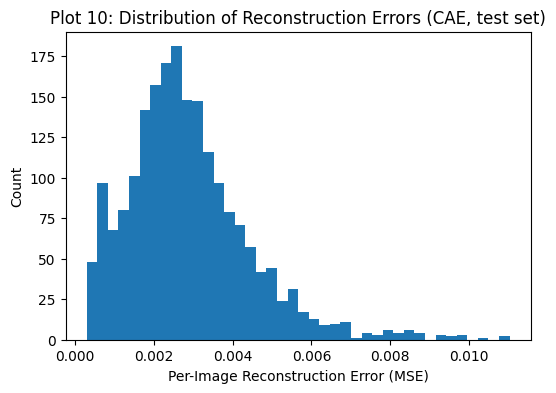

Mean error: 0.00288   Std: 0.00156   Min: 0.00031   Max: 0.01102


In [ ]:
per_image_error = np.mean((x_test_cnn - recon_cae_test) ** 2, axis=(1, 2, 3))

plt.figure(figsize=(6, 4))
plt.hist(per_image_error, bins=40)
plt.xlabel('Per-Image Reconstruction Error (MSE)')
plt.ylabel('Count')
plt.title('Plot 10: Distribution of Reconstruction Errors (CAE, test set)')
plt.show()

print(f"Mean error: {per_image_error.mean():.5f}   Std: {per_image_error.std():.5f}   "
      f"Min: {per_image_error.min():.5f}   Max: {per_image_error.max():.5f}")

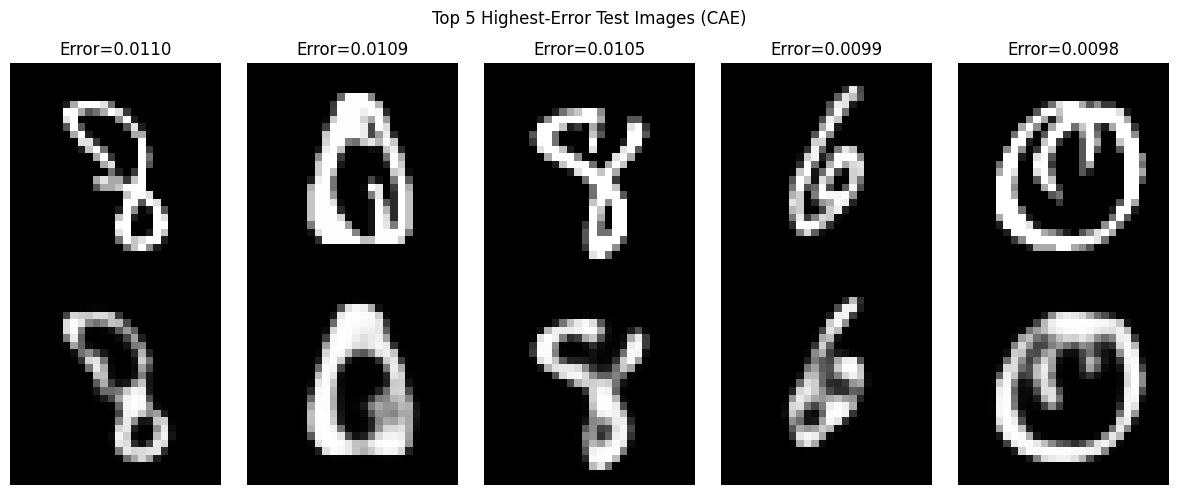

,Sample,Test Index,True Label,Reconstruction Error (MSE)
0,1,543,8,0.011023
1,2,895,0,0.010864
2,3,1125,8,0.010459
3,4,1908,6,0.009876
4,5,1526,0,0.009845


In [ ]:
top5_idx = np.argsort(per_image_error)[-5:][::-1]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for col, idx in enumerate(top5_idx):
    axes[0, col].imshow(x_test[idx], cmap='gray')
    axes[0, col].set_title(f'Error={per_image_error[idx]:.4f}')
    axes[0, col].axis('off')
    axes[1, col].imshow(recon_cae_test[idx].reshape(28, 28), cmap='gray')
    axes[1, col].axis('off')
axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('Reconstruction')
plt.suptitle('Top 5 Highest-Error Test Images (CAE)')
plt.tight_layout()
plt.show()

high_error_table = pd.DataFrame({
    'Sample': range(1, 6),
    'Test Index': top5_idx,
    'True Label': y_test[top5_idx],
    'Reconstruction Error (MSE)': per_image_error[top5_idx]
})
high_error_table

In [ ]:
consolidated_df = pd.DataFrame({
    'Model': ['FC Autoencoder', 'Conv. Autoencoder', 'Denoising CAE', 'VAE'],
    'MSE': [mse_fc, mse_cae, mse_dn, mse_vae],
    'MAE': [mae_fc, mae_cae, mae_dn, mae_vae],
    'SSIM': [ssim_fc, ssim_cae, ssim_dn, ssim_vae],
    'Parameters': [
        fc_ae.count_params(), cae.count_params(), denoise_cae.count_params(),
        encoder.count_params() + decoder.count_params()
    ],
    'Training Time (s)': [time_fc, time_cae, time_denoise, time_vae]
})
consolidated_df

,Model,MSE,MAE,SSIM,Parameters,Training Time (s)
0,FC Autoencoder,0.025793,0.065904,0.697924,211040,12.969162
1,Conv. Autoencoder,0.002881,0.015834,0.971676,74497,18.540205
2,Denoising CAE,0.005158,0.022615,0.940166,74497,15.709414
3,VAE,0.048956,0.114731,0.411750,134165,19.294620


In [ ]:
latent_dims = [2, 8, 16, 32]
LD_EPOCHS = 8

ld_results = []
for dz in latent_dims:
    model = build_fc_autoencoder(dz)
    model.fit(x_train_flat, x_train_flat, epochs=LD_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    recon = model.predict(x_test_flat, verbose=0)
    mse_d, mae_d, ssim_d = compute_metrics(
        x_test_flat.reshape(-1, 28, 28, 1), recon.reshape(-1, 28, 28, 1)
    )
    ld_results.append({'Latent Dimension': dz, 'MSE': mse_d, 'SSIM': ssim_d, 'Parameters': model.count_params()})
    print(f"dz={dz:>3d}  ->  MSE={mse_d:.5f}  SSIM={ssim_d:.4f}")

ld_df = pd.DataFrame(ld_results)
ld_df

dz=  2  ->  MSE=0.05185  SSIM=0.3774
dz=  8  ->  MSE=0.03675  SSIM=0.5801
dz= 16  ->  MSE=0.03033  SSIM=0.6428
dz= 32  ->  MSE=0.02613  SSIM=0.6836


,Latent Dimension,MSE,SSIM,Parameters
0,2,0.051848,0.377354,210130
1,8,0.036750,0.580070,210520
2,16,0.030333,0.642782,211040
3,32,0.026127,0.683635,212080


**Plot 11: Latent Dimension vs Reconstruction MSE**


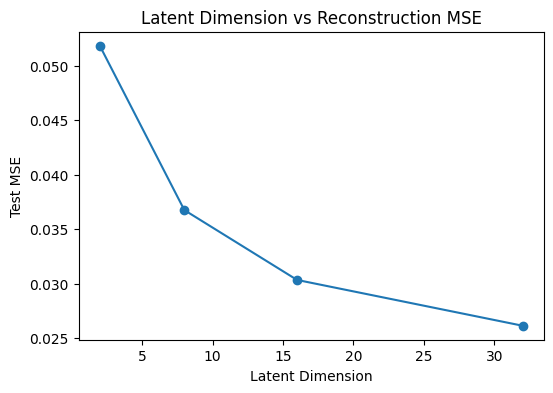

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(ld_df['Latent Dimension'], ld_df['MSE'], marker='o')
plt.xlabel('Latent Dimension')
plt.ylabel('Test MSE')
plt.title('Latent Dimension vs Reconstruction MSE')
plt.show()

In [ ]:
# Reusable CAE with a configurable dense latent bottleneck.
def build_cae_with_latent(latent_dim):
    inp = tf.keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D(2, padding='same')(x)      # 14x14x32
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)      # 7x7x64
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    shape_before_flatten = x.shape[1:]
    x = layers.Flatten()(x)
    z = layers.Dense(latent_dim, name='latent')(x)

    x = layers.Dense(int(np.prod(shape_before_flatten)), activation='relu')(z)
    x = layers.Reshape(shape_before_flatten)(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

    model = tf.keras.Model(inp, out, name=f'CAE_latent_{latent_dim}')
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy')
    return model

latent_dims_cae = [4, 8, 16, 32]
cae_latent_results = []

for d in latent_dims_cae:
    model = build_cae_with_latent(d)
    model.fit(
        x_train_cnn, x_train_cnn,
        validation_data=(x_val_cnn, x_val_cnn),
        epochs=8, batch_size=128, verbose=0
    )
    pred = model.predict(x_test_cnn, verbose=0)
    mse_d, mae_d, ssim_d = compute_metrics(x_test_cnn, pred)
    params_d = model.count_params()
    cae_latent_results.append([d, mse_d, ssim_d, params_d])

cae_latent_results

[[4, 0.03574676439166069, 0.6128185661637097, 102725],
 [8, 0.022748926654458046, 0.7597982578978129, 127817],
 [16, 0.012389826588332653, 0.8718711581962696, 178001],
 [32, 0.008956878446042538, 0.9087739174012199, 278369]]

,Latent Dimension,MSE,SSIM,Parameters
0,4,0.035747,0.612819,102725
1,8,0.022749,0.759798,127817
2,16,0.012390,0.871871,178001
3,32,0.008957,0.908774,278369


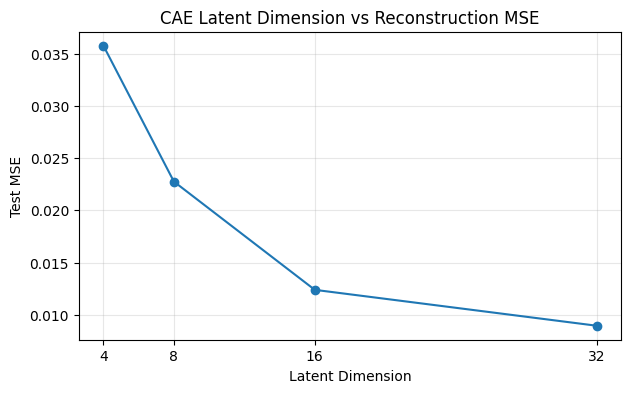

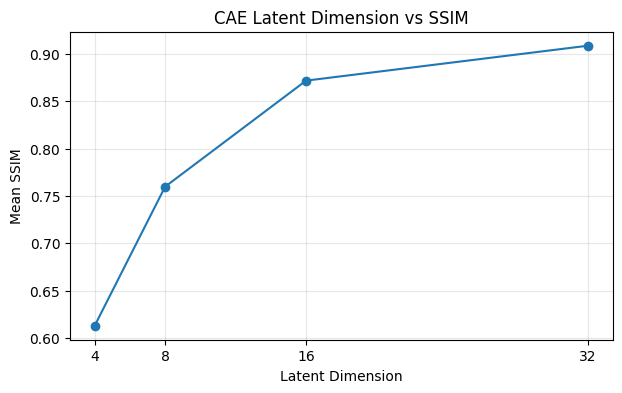

In [ ]:
# Report and plot the latent-dimension comparison.
import pandas as pd

cae_latent_df = pd.DataFrame(
    cae_latent_results,
    columns=['Latent Dimension', 'MSE', 'SSIM', 'Parameters']
)
display(cae_latent_df)

plt.figure(figsize=(7, 4))
plt.plot(cae_latent_df['Latent Dimension'], cae_latent_df['MSE'], marker='o')
plt.xlabel('Latent Dimension')
plt.ylabel('Test MSE')
plt.title('CAE Latent Dimension vs Reconstruction MSE')
plt.xticks(latent_dims_cae)
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(cae_latent_df['Latent Dimension'], cae_latent_df['SSIM'], marker='o')
plt.xlabel('Latent Dimension')
plt.ylabel('Mean SSIM')
plt.title('CAE Latent Dimension vs SSIM')
plt.xticks(latent_dims_cae)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Compare both corruption types at representative levels.
gaussian_levels = [0.1, 0.2, 0.3]
sp_levels = [0.05, 0.10, 0.20]

noise_comparison = []

for sigma in gaussian_levels:
    noisy = add_gaussian_noise(x_test_cnn, sigma)
    pred = denoise_cae.predict(noisy, verbose=0)
    mse_v, mae_v, ssim_v = compute_metrics(x_test_cnn, pred)
    noise_comparison.append(['Gaussian', sigma, mse_v, mae_v, ssim_v])

for p in sp_levels:
    noisy = add_salt_pepper_noise(x_test_cnn, p)
    pred = denoise_cae.predict(noisy, verbose=0)
    mse_v, mae_v, ssim_v = compute_metrics(x_test_cnn, pred)
    noise_comparison.append(['Salt-and-Pepper', p, mse_v, mae_v, ssim_v])

noise_comparison_df = pd.DataFrame(
    noise_comparison,
    columns=['Noise Type', 'Level', 'MSE', 'MAE', 'SSIM']
)
display(noise_comparison_df)

,Noise Type,Level,MSE,MAE,SSIM
0,Gaussian,0.10,0.004058,0.019077,0.956094
1,Gaussian,0.20,0.005147,0.022589,0.939417
2,Gaussian,0.30,0.007663,0.030177,0.879894
3,Salt-and-Pepper,0.05,0.004716,0.020482,0.947198
4,Salt-and-Pepper,0.10,0.005867,0.023559,0.927232
5,Salt-and-Pepper,0.20,0.010060,0.034309,0.838085


In [ ]:
def train_gaussian_denoiser(sigma, epochs=8):
    noisy_train = add_gaussian_noise(x_train_cnn, sigma)
    noisy_val = add_gaussian_noise(x_val_cnn, sigma)

    model = build_conv_autoencoder()
    model.fit(
        noisy_train, x_train_cnn,
        validation_data=(noisy_val, x_val_cnn),
        epochs=epochs, batch_size=128, verbose=0
    )
    return model

noise_models = {}
for sigma in [0.1, 0.3]:
    noise_models[sigma] = train_gaussian_denoiser(sigma)

rows = []
for train_sigma, model in noise_models.items():
    for eval_sigma in [0.1, 0.2, 0.3]:
        noisy_test = add_gaussian_noise(x_test_cnn, eval_sigma)
        pred = model.predict(noisy_test, verbose=0)
        _, _, ssim_v = compute_metrics(x_test_cnn, pred)
        rows.append([train_sigma, eval_sigma, ssim_v])

denoising_transfer_df = pd.DataFrame(
    rows, columns=['Training Sigma', 'Evaluation Sigma', 'SSIM']
)
display(denoising_transfer_df)

,Training Sigma,Evaluation Sigma,SSIM
0,0.1,0.1,0.953186
1,0.1,0.2,0.896208
2,0.1,0.3,0.710664
3,0.3,0.1,0.938256
4,0.3,0.2,0.928146
5,0.3,0.3,0.900774


In [ ]:
def build_cae_transpose():
    inp = tf.keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)

    x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu',
                               padding='same')(x)
    x = layers.Conv2DTranspose(16, 3, strides=2, activation='relu',
                               padding='same')(x)
    out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

    model = tf.keras.Model(inp, out, name='CAE_Conv2DTranspose')
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy')
    return model

cae_transpose = build_cae_transpose()
cae_transpose.fit(
    x_train_cnn, x_train_cnn,
    validation_data=(x_val_cnn, x_val_cnn),
    epochs=8, batch_size=128, verbose=0
)

pred_transpose = cae_transpose.predict(x_test_cnn, verbose=0)
mse_t, mae_t, ssim_t = compute_metrics(x_test_cnn, pred_transpose)

print(f"Conv2DTranspose decoder — MSE: {mse_t:.5f}, MAE: {mae_t:.5f}, SSIM: {ssim_t:.4f}")

Conv2DTranspose decoder — MSE: 0.00345, MAE: 0.01737, SSIM: 0.9658


Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - kl_loss: 1.1759 - loss: 42.2901 - reconstruction_loss: 41.1142 - val_kl_loss: 0.5217 - val_loss: 32.6545 - val_reconstruction_loss: 32.1328
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 0.6614 - loss: 32.8717 - reconstruction_loss: 32.2103 - val_kl_loss: 0.8650 - val_loss: 32.0265 - val_reconstruction_loss: 31.1615
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 0.9547 - loss: 32.4190 - reconstruction_loss: 31.4642 - val_kl_loss: 1.0743 - val_loss: 31.6803 - val_reconstruction_loss: 30.6060
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 1.2050 - loss: 31.9773 - reconstruction_loss: 30.7722 - val_kl_loss: 1.4061 - val_loss: 31.0106 - val_reconstruction_loss: 29.6045
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 1.5966 - loss: 31.4780 - reconstruction_loss: 29.8814 - val_kl_loss: 1.6620 - val_loss: 30.6763 - val_reconstruction_loss: 29.0143
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 

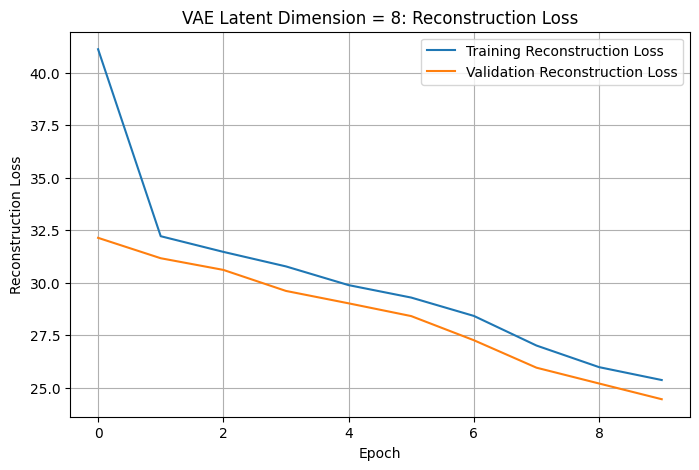

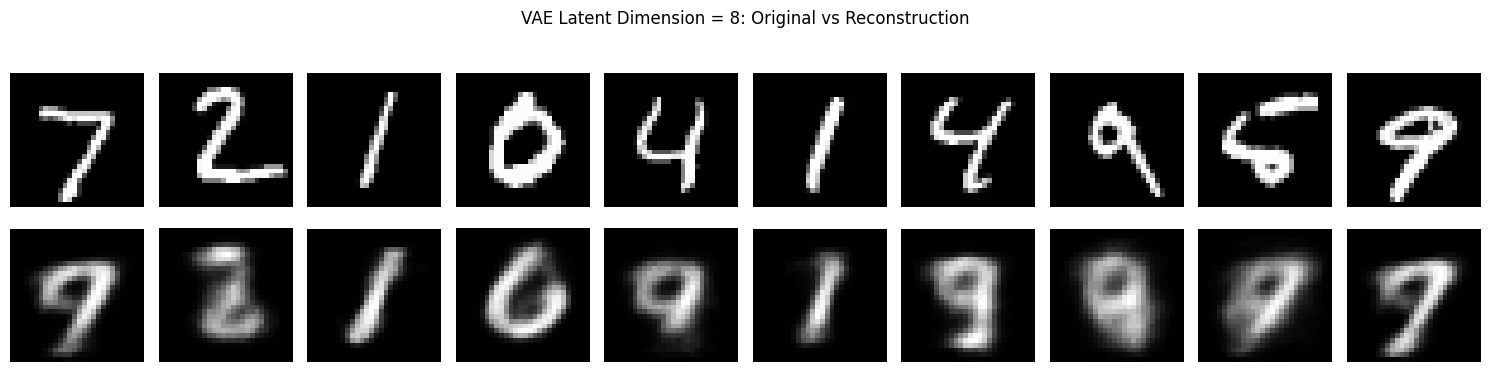


Additional Exercise 5
VAE latent dimension comparison
Latent dimension 8: MSE=0.04601, MAE=0.10681, SSIM=0.4493

The latent dimension 2 VAE results are obtained from the main VAE experiment above.

Inference prompt:
Compare the latent representations for dimensions 2 and 8.
Discuss how increasing the latent dimension affects compression and reconstruction quality.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt


def build_dense_vae(latent_dim):

    encoder_inputs = keras.Input(shape=(784,), name="encoder_input")

    x = layers.Dense(256, activation="relu")(encoder_inputs)
    x = layers.Dense(128, activation="relu")(x)

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

    def sampling(args):
        z_mean, z_log_var = args

        epsilon = tf.random.normal(
            shape=tf.shape(z_mean),
            mean=0.0,
            stddev=1.0
        )

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    z = layers.Lambda(
        sampling,
        name="z"
    )([z_mean, z_log_var])

    encoder = keras.Model(
        encoder_inputs,
        [z_mean, z_log_var, z],
        name=f"encoder_latent_{latent_dim}"
    )

    latent_inputs = keras.Input(
        shape=(latent_dim,),
        name="decoder_input"
    )

    x = layers.Dense(128, activation="relu")(latent_inputs)
    x = layers.Dense(256, activation="relu")(x)

    decoder_outputs = layers.Dense(
        784,
        activation="sigmoid"
    )(x)

    decoder = keras.Model(
        latent_inputs,
        decoder_outputs,
        name=f"decoder_latent_{latent_dim}"
    )

    class DenseVAE(keras.Model):

        def __init__(self, encoder, decoder, **kwargs):
            super().__init__(**kwargs)
            self.encoder = encoder
            self.decoder = decoder

            self.total_loss_tracker = keras.metrics.Mean(
                name="total_loss"
            )

            self.reconstruction_loss_tracker = keras.metrics.Mean(
                name="reconstruction_loss"
            )

            self.kl_loss_tracker = keras.metrics.Mean(
                name="kl_loss"
            )

        @property
        def metrics(self):
            return [
                self.total_loss_tracker,
                self.reconstruction_loss_tracker,
                self.kl_loss_tracker
            ]

        def train_step(self, data):

            if isinstance(data, tuple):
                x = data[0]
            else:
                x = data

            with tf.GradientTape() as tape:

                z_mean, z_log_var, z = self.encoder(
                    x,
                    training=True
                )

                reconstruction = self.decoder(
                    z,
                    training=True
                )

                reconstruction_loss = tf.reduce_mean(
                    tf.reduce_sum(
                        keras.losses.binary_crossentropy(
                            x,
                            reconstruction
                        ),
                        axis=-1
                    )
                )

                kl_loss = -0.5 * tf.reduce_mean(
                    tf.reduce_sum(
                        1
                        + z_log_var
                        - tf.square(z_mean)
                        - tf.exp(z_log_var),
                        axis=-1
                    )
                )

                total_loss = reconstruction_loss + kl_loss

            gradients = tape.gradient(
                total_loss,
                self.trainable_weights
            )

            self.optimizer.apply_gradients(
                zip(gradients, self.trainable_weights)
            )

            self.total_loss_tracker.update_state(total_loss)
            self.reconstruction_loss_tracker.update_state(
                reconstruction_loss
            )
            self.kl_loss_tracker.update_state(kl_loss)

            return {
                "loss": self.total_loss_tracker.result(),
                "reconstruction_loss":
                    self.reconstruction_loss_tracker.result(),
                "kl_loss":
                    self.kl_loss_tracker.result()
            }

        def test_step(self, data):

            if isinstance(data, tuple):
                x = data[0]
            else:
                x = data

            z_mean, z_log_var, z = self.encoder(
                x,
                training=False
            )

            reconstruction = self.decoder(
                z,
                training=False
            )

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(
                        x,
                        reconstruction
                    ),
                    axis=-1
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1
                    + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=-1
                )
            )

            total_loss = reconstruction_loss + kl_loss

            self.total_loss_tracker.update_state(total_loss)
            self.reconstruction_loss_tracker.update_state(
                reconstruction_loss
            )
            self.kl_loss_tracker.update_state(kl_loss)

            return {
                "loss": self.total_loss_tracker.result(),
                "reconstruction_loss":
                    self.reconstruction_loss_tracker.result(),
                "kl_loss":
                    self.kl_loss_tracker.result()
            }

    vae = DenseVAE(
        encoder,
        decoder,
        name=f"vae_latent_{latent_dim}"
    )

    vae.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        )
    )

    return vae, encoder, decoder


vae8, encoder8, decoder8 = build_dense_vae(8)

history_vae8 = vae8.fit(
    x_train_flat,
    x_train_flat,
    validation_data=(
        x_val_flat,
        x_val_flat
    ),
    epochs=10,
    batch_size=128,
    verbose=1
)

z_mean8, z_log_var8, z8 = encoder8.predict(
    x_test_flat,
    verbose=0
)

recon8 = decoder8.predict(
    z8,
    verbose=0
)

mse8, mae8, ssim8 = compute_metrics(
    x_test_flat.reshape(-1, 28, 28, 1),
    recon8.reshape(-1, 28, 28, 1)
)

print(
    f"VAE latent=8 - "
    f"MSE: {mse8:.5f}, "
    f"MAE: {mae8:.5f}, "
    f"SSIM: {ssim8:.4f}"
)

plt.figure(figsize=(8, 5))

plt.plot(
    history_vae8.history["reconstruction_loss"],
    label="Training Reconstruction Loss"
)

plt.plot(
    history_vae8.history["val_reconstruction_loss"],
    label="Validation Reconstruction Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("VAE Latent Dimension = 8: Reconstruction Loss")
plt.legend()
plt.grid(True)
plt.show()

n = 10

plt.figure(figsize=(15, 4))

for i in range(n):

    ax = plt.subplot(2, n, i + 1)
    plt.imshow(
        x_test_flat[i].reshape(28, 28),
        cmap="gray"
    )
    plt.axis("off")

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(
        recon8[i].reshape(28, 28),
        cmap="gray"
    )
    plt.axis("off")

plt.suptitle(
    "VAE Latent Dimension = 8: Original vs Reconstruction"
)

plt.tight_layout()
plt.show()

print("\nAdditional Exercise 5")
print("=" * 60)
print("VAE latent dimension comparison")
print("=" * 60)

print(
    f"Latent dimension 8:"
    f" MSE={mse8:.5f},"
    f" MAE={mae8:.5f},"
    f" SSIM={ssim8:.4f}"
)

print(
    "\nThe latent dimension 2 VAE results are obtained "
    "from the main VAE experiment above."
)

print(
    "\nInference prompt:"
    "\nCompare the latent representations for dimensions "
    "2 and 8."
    "\nDiscuss how increasing the latent dimension affects "
    "compression and reconstruction quality."
)

In [ ]:
beta_values = [0.1, 1.0, 2.0]
beta_results = []

for beta in beta_values:
    vae_b, enc_b, dec_b = build_dense_vae(2)
    vae_b.beta = beta
    vae_b.fit(
        x_train_flat, x_train_flat,
        validation_data=(x_val_flat, x_val_flat),
        epochs=8, batch_size=128, verbose=0
    )

    metrics_b = vae_b.evaluate(x_test_flat, x_test_flat, verbose=0, return_dict=True)
    beta_results.append([
        beta,
        metrics_b.get('recon_loss', np.nan),
        metrics_b.get('kl_loss', np.nan),
        metrics_b.get('loss', np.nan)
    ])

beta_df = pd.DataFrame(
    beta_results,
    columns=['Beta', 'Reconstruction Loss', 'KL Loss', 'Total Loss']
)
display(beta_df)

,Beta,Reconstruction Loss,KL Loss,Total Loss
0,0.1,NaN,"tf.Tensor(1.7411071, shape=(), dtype=float32)","tf.Tensor(8.7511635, shape=(), dtype=float32)"
1,1.0,NaN,"tf.Tensor(1.8330764, shape=(), dtype=float32)","tf.Tensor(8.856272, shape=(), dtype=float32)"
2,2.0,NaN,"tf.Tensor(1.5059396, shape=(), dtype=float32)","tf.Tensor(8.701802, shape=(), dtype=float32)"


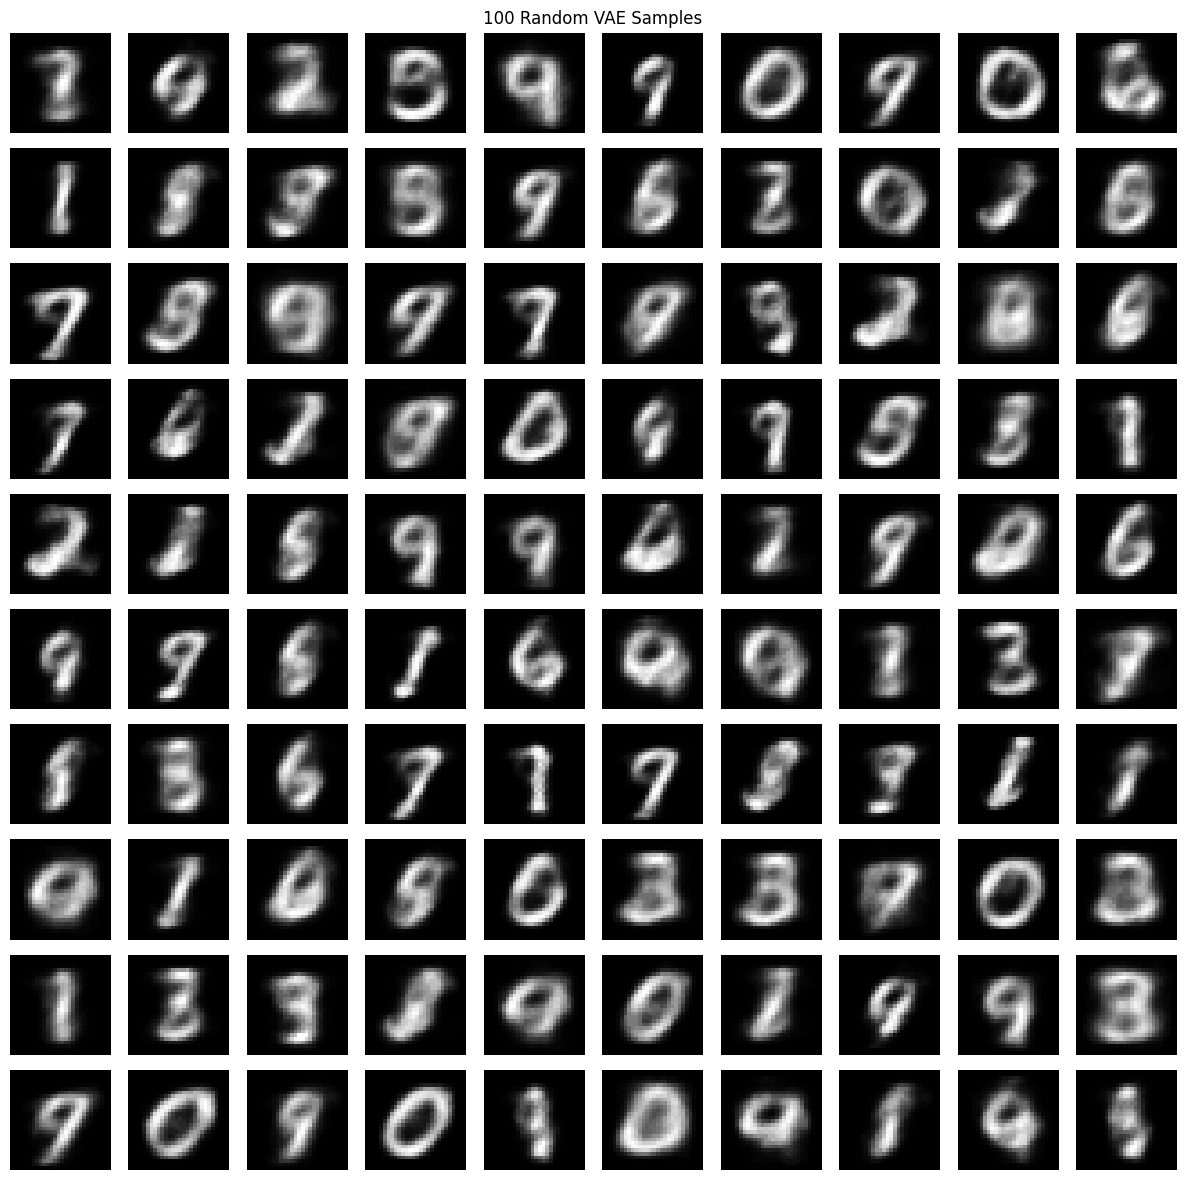

In [ ]:
n_samples_large = 100

z_samples_large = np.random.normal(
    size=(n_samples_large, 8)
).astype("float32")

generated_large = decoder8.predict(
    z_samples_large,
    verbose=0
).reshape(-1, 28, 28)

fig, axes = plt.subplots(
    10,
    10,
    figsize=(12, 12)
)

for ax, img in zip(
    axes.ravel(),
    generated_large
):
    ax.imshow(
        img,
        cmap="gray"
    )
    ax.axis("off")

plt.suptitle("100 Random VAE Samples")
plt.tight_layout()
plt.show()

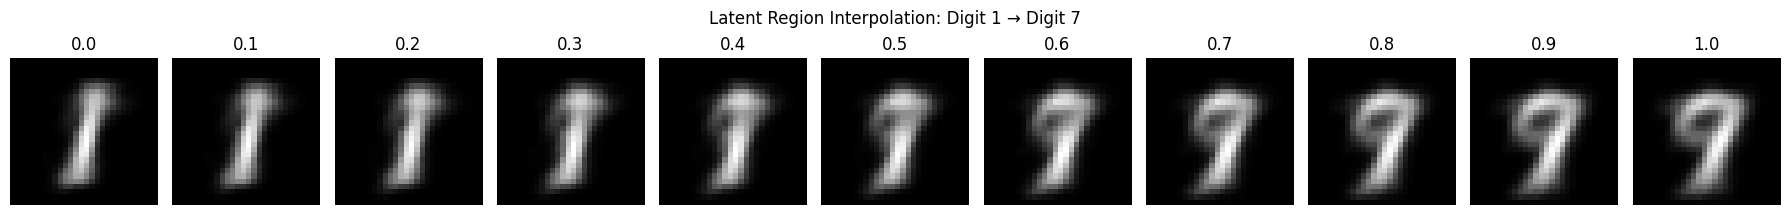

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

vae2, vae_encoder, vae_decoder = build_dense_vae(2)

vae2.fit(
    x_train_flat,
    x_train_flat,
    validation_data=(x_val_flat, x_val_flat),
    epochs=10,
    batch_size=128,
    verbose=0
)

z_mean_test, _, _ = vae_encoder.predict(
    x_test_flat,
    verbose=0
)

digit_a = 1
digit_b = 7

idx_a = np.where(y_test[:len(z_mean_test)] == digit_a)[0]
idx_b = np.where(y_test[:len(z_mean_test)] == digit_b)[0]

if len(idx_a) == 0 or len(idx_b) == 0:
    raise ValueError(
        "Selected digit labels were not found in the encoded test subset."
    )

zA = z_mean_test[idx_a].mean(axis=0)
zB = z_mean_test[idx_b].mean(axis=0)

alphas = np.linspace(0, 1, 11)

z_interp_regions = np.array([
    (1 - a) * zA + a * zB
    for a in alphas
])

interp_region_images = vae_decoder.predict(
    z_interp_regions,
    verbose=0
).reshape(-1, 28, 28)

fig, axes = plt.subplots(
    1,
    11,
    figsize=(18, 2.2)
)

for i, (ax, img, a) in enumerate(
    zip(axes, interp_region_images, alphas)
):
    ax.imshow(
        img,
        cmap="gray"
    )
    ax.set_title(f"{a:.1f}")
    ax.axis("off")

plt.suptitle(
    f"Latent Region Interpolation: Digit {digit_a} → Digit {digit_b}"
)

plt.tight_layout()
plt.show()

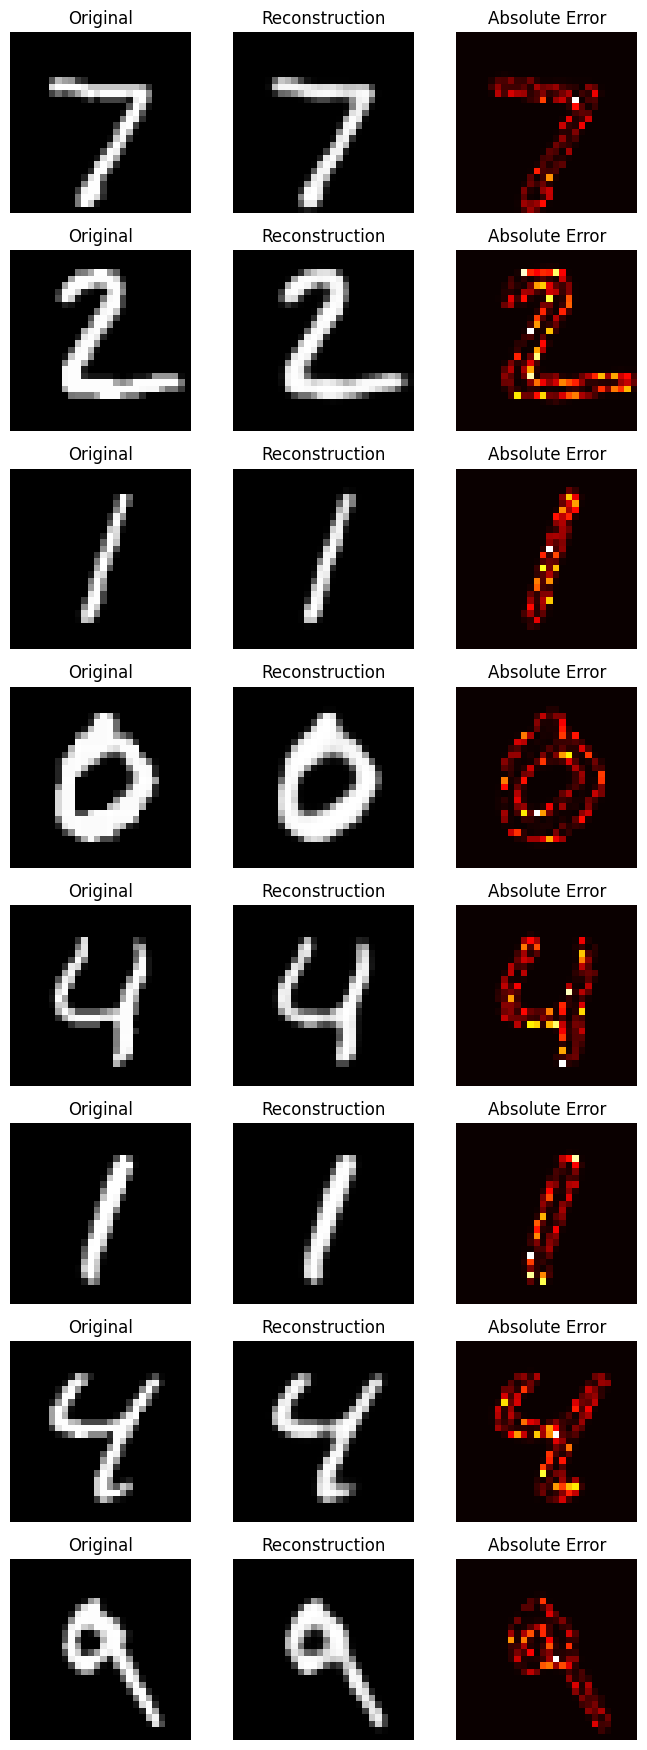

In [ ]:
n_error_maps = 8
sample_idx = np.arange(n_error_maps)

test_pred_cnn = cae.predict(
    x_test_cnn,
    verbose=0
)

fig, axes = plt.subplots(
    n_error_maps,
    3,
    figsize=(7, 2.2 * n_error_maps)
)

for row, idx in enumerate(sample_idx):
    original = x_test_cnn[idx, ..., 0]
    reconstructed = test_pred_cnn[idx, ..., 0]
    error = np.abs(original - reconstructed)

    axes[row, 0].imshow(
        original,
        cmap="gray"
    )
    axes[row, 0].set_title("Original")

    axes[row, 1].imshow(
        reconstructed,
        cmap="gray"
    )
    axes[row, 1].set_title("Reconstruction")

    axes[row, 2].imshow(
        error,
        cmap="hot"
    )
    axes[row, 2].set_title("Absolute Error")

    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()